In [ ]:
def prob_sum(p, q, v):
    if v == 3:
        return p * q
    elif v == 4:
        return p * (1 - q) + (1 - p) * q
    elif v == 5:
        return (1 - p) * (1 - q)
    else:
        return 0

In [ ]:
import numpy as np

def log_likelihood(p, q, X):
    X = np.array(X)
    
    n3 = np.sum(X == 3)
    n4 = np.sum(X == 4)
    n5 = np.sum(X == 5)
    
    p3 = p * q
    p4 = p * (1 - q) + (1 - p) * q
    p5 = (1 - p) * (1 - q)
    
    return (
        n3 * np.log(p3) +
        n4 * np.log(p4) +
        n5 * np.log(p5)
    )

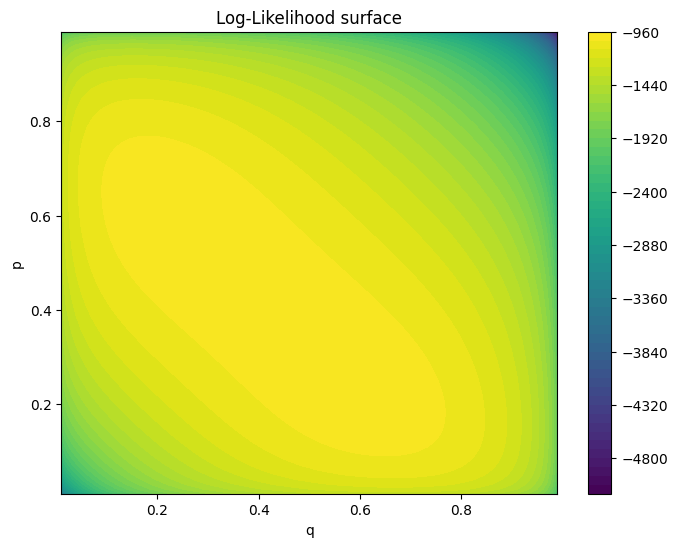

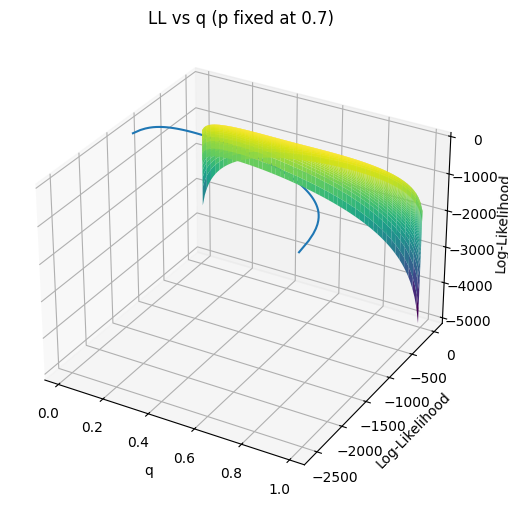

25 56
MLE: p=0.4125, q=0.4125, Log-Likelihood=-988.84
MLE: p=0.5613, q=0.2637, Log-Likelihood=-984.63


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

n3, n4, n5 = 148, 529, 323

def log_likelihood(p, q):
    if p <= 0 or p >= 1 or q <= 0 or q >= 1:
        return -np.inf
    
    p3 = p * q
    p4 = p * (1 - q) + (1 - p) * q
    p5 = (1 - p) * (1 - q)
    
    if min(p3, p4, p5) <= 0:
        return -np.inf
    
    return n3*np.log(p3) + n4*np.log(p4) + n5*np.log(p5)

p_values = np.linspace(0.01, 0.99, 100)
q_values = np.linspace(0.01, 0.99, 100)

LL = np.zeros((100, 100))

for i, p in enumerate(p_values):
    for j, q in enumerate(q_values):
        LL[i, j] = log_likelihood(p, q)

P, Q = np.meshgrid(q_values, p_values)

plt.figure(figsize=(8,6))
cp = plt.contourf(P, Q, LL, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('q')
plt.ylabel('p')
plt.title('Log-Likelihood surface')
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(P, Q, LL, cmap='viridis')
ax.set_xlabel('q')
ax.set_ylabel('p')
ax.set_zlabel('Log-Likelihood')
plt.plot(q_values, [log_likelihood(0.7, q) for q in q_values])
plt.xlabel('q')
plt.ylabel('Log-Likelihood')
plt.title('LL vs q (p fixed at 0.7)')
plt.show()
i_max, j_max = np.unravel_index(np.argmax(LL), LL.shape)
p_mle = p_values[i_max]
q_mle = q_values[j_max]
print(i_max, j_max)

def neg_log_likelihood(params):
    p, q = params
    # Обмеження на [0,1]
    if p <= 0 or p >= 1 or q <= 0 or q >= 1:
        return np.inf
    
    p3 = p*q
    p4 = p*(1-q) + (1-p)*q
    p5 = (1-p)*(1-q)
    
    # Щоб уникнути log(0)
    if min(p3,p4,p5) <= 0:
        return np.inf
    
    LL = n3*np.log(p3) + n4*np.log(p4) + n5*np.log(p5)
    return -LL  # Мінус, бо ми мінімізуємо

# Початкові точки (можна дві дзеркальні, щоб знайти обидва максимуми)
initial_guesses = [
    [0.5, 0.5],
    [0.8, 0.2]
]

results = []
for guess in initial_guesses:
    res = minimize(neg_log_likelihood, guess, bounds=[(0.01,0.99),(0.01,0.99)])
    results.append(res)

for r in results:
    p_mle, q_mle = r.x
    print(f"MLE: p={p_mle:.4f}, q={q_mle:.4f}, Log-Likelihood={-r.fun:.2f}")
# Будуть два дзеркальні максимуми через симетрію: (p, q) ~ (0.7, 0.21); (0.79, 0,31) 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 54.4 MB/s eta 0:00:001m45.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 99.4 MB/s eta 0:00:00


In [5]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 119.1 MB/s eta 0:00:00m eta 0:00:01


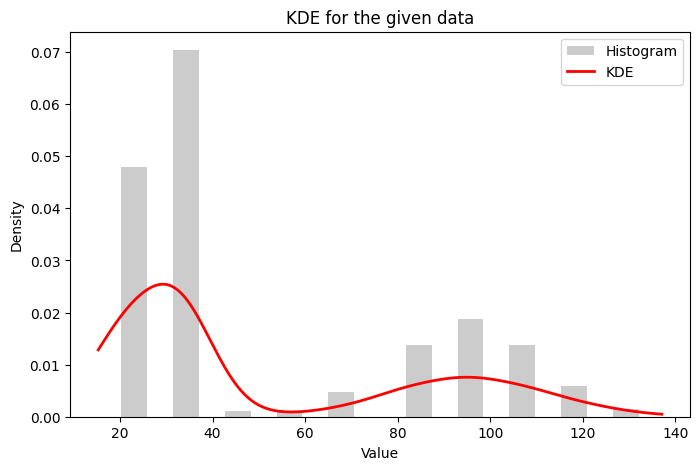

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

values = np.array([20.3, 32.7, 45.2, 57.6, 70, 82.4, 94.9, 107.3, 119.7, 132.1])
counts = np.array([402, 590, 10, 9, 39, 116, 157, 115, 50, 12])

# Створюємо “плоский” масив, який повторює значення згідно counts
data = np.repeat(values, counts)

# Gaussian KDE using Silverman
kde = gaussian_kde(data)  # bandwidth автоматично обчислюється
x_grid = np.linspace(min(data)-5, max(data)+5, 1000)
kde_values = kde(x_grid)

# Візуалізація
plt.figure(figsize=(8,5))
plt.hist(data, bins=20, density=True, alpha=0.4, color='gray', label='Histogram')
plt.plot(x_grid, kde_values, color='red', lw=2, label='KDE')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('KDE for the given data')
plt.legend()
plt.show()